In [1]:
# Imports
from os import listdir
from os.path import isfile, join
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from timeit import default_timer as timer
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import regularizers, optimizers
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Activation, MaxPooling1D, Dropout, LSTM
from tensorflow.keras.utils import plot_model, to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils import class_weight
from sklearn.preprocessing import label_binarize

np.random.seed(10)
from tensorflow.keras import backend as K
K.clear_session()


In [3]:
pip install streamlit librosa tensorflow matplotlib

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -------------------------------


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from tensorflow.keras.models import load_model

model = load_model('final_model.h5')
print("Model loaded successfully.")

Model loaded successfully.


In [18]:
# Diagnosis Class
class Diagnosis():
    def __init__ (self, id, diagnosis, image_path):
        self.id = id
        self.diagnosis = diagnosis 
        self.image_path = image_path   

In [19]:
# get_wav_files function
def get_wav_files():
    audio_path = 'extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/'
    files = [f for f in listdir(audio_path) if isfile(join(audio_path, f))]
    wav_files = [f for f in files if f.endswith('.wav')]
    wav_files = sorted(wav_files)
    return wav_files, audio_path

In [20]:
# diagnosis_data function
def diagnosis_data():
    diagnosis = pd.read_csv('extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv')
    
    wav_files, audio_path = get_wav_files()
    diag_dict = { 101 : "URTI"}   
    diagnosis_list = []
    
    for index , row in diagnosis.iterrows():
        diag_dict[row[0]] = row.iloc[1]     

    c = 0
    for f in wav_files:
        diagnosis_list.append(Diagnosis(c, diag_dict[int(f[:3])], audio_path+f))
        c+=1

    return diagnosis_list

In [21]:
# audio_features function
def audio_features(filename):
    """
    Extracts features from an audio file without any data augmentation.
    This function is now safe to use with any .wav file.
    """
    try:
        sound, sample_rate = librosa.load(filename)
        stft = np.abs(librosa.stft(sound))
        
        mfccs = np.mean(librosa.feature.mfcc(y=sound, sr=sample_rate, n_mfcc=40),axis=1)
        chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate),axis=1)
        mel = np.mean(librosa.feature.melspectrogram(y=sound, sr=sample_rate), axis=1)
        contrast = np.mean(librosa.feature.spectral_contrast(S=stft, sr=sample_rate),axis=1)
        tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(sound), sr=sample_rate),axis=1)
            
        concat = np.concatenate((mfccs,chroma,mel,contrast,tonnetz))
        return concat
    except Exception as e:
        print(f"Error processing file {filename}: {e}")
        return None

# Data Points function
def data_points():
    labels = []
    images = []

    to_hot_one = {"COPD":0, "Healthy":1, "URTI":2, "Bronchiectasis":3, "Pneumonia":4, "Bronchiolitis":5, "Asthma":6, "LRTI":7}

    count = 0
    diagnosis_list = diagnosis_data()
    for f in diagnosis_list:
        print(f"Processing {count+1}/{len(diagnosis_list)}: {f.image_path}")
        
        try:
            # Data augmentation for minority classes
            diagnosis_label = f.diagnosis
            if diagnosis_label in ["URTI", "Bronchiectasis", "Pneumonia", "Bronchiolitis"]:
                for _ in range(5):
                    sound, sample_rate = librosa.load(f.image_path)
                    
                    noise = np.random.randn(len(sound))
                    sound_augmented = sound + 0.005 * noise
                    
                    stft = np.abs(librosa.stft(sound_augmented))
                    mfccs = np.mean(librosa.feature.mfcc(y=sound_augmented, sr=sample_rate, n_mfcc=40), axis=1)
                    chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate), axis=1)
                    mel = np.mean(librosa.feature.melspectrogram(y=sound_augmented, sr=sample_rate), axis=1)
                    contrast = np.mean(librosa.feature.spectral_contrast(S=stft, sr=sample_rate), axis=1)
                    tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(sound_augmented), sr=sample_rate), axis=1)
                    concat = np.concatenate((mfccs, chroma, mel, contrast, tonnetz))
                    
                    labels.append(to_hot_one[diagnosis_label])
                    images.append(concat)

            sound, sample_rate = librosa.load(f.image_path)
            stft = np.abs(librosa.stft(sound))
            mfccs = np.mean(librosa.feature.mfcc(y=sound, sr=sample_rate, n_mfcc=40), axis=1)
            chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate), axis=1)
            mel = np.mean(librosa.feature.melspectrogram(y=sound, sr=sample_rate), axis=1)
            contrast = np.mean(librosa.feature.spectral_contrast(S=stft, sr=sample_rate), axis=1)
            tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(sound), sr=sample_rate), axis=1)
            concat = np.concatenate((mfccs, chroma, mel, contrast, tonnetz))
            
            labels.append(to_hot_one[diagnosis_label])
            images.append(concat)
        
        except Exception as e:
            print(f"Error processing file: {f.image_path}. Skipping this file. Error: {e}")
            
        count += 1

    return np.array(labels), np.array(images)

C:\Users\NAMAN\AppData\Local\Temp\ipykernel_20472\1291806968.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  diag_dict[row[0]] = row.iloc[1]


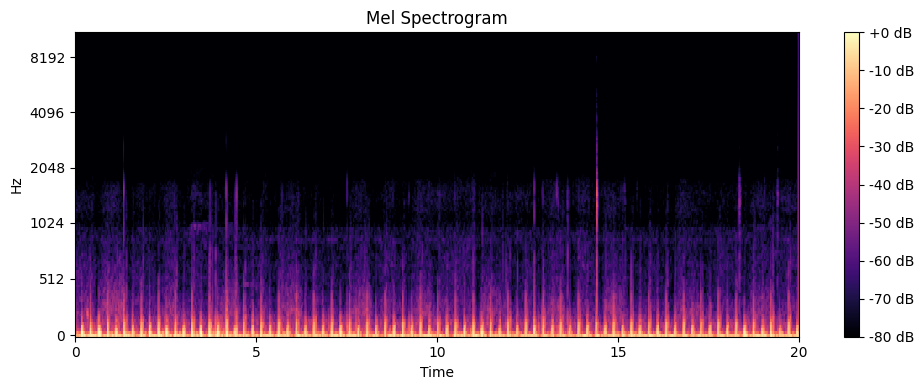

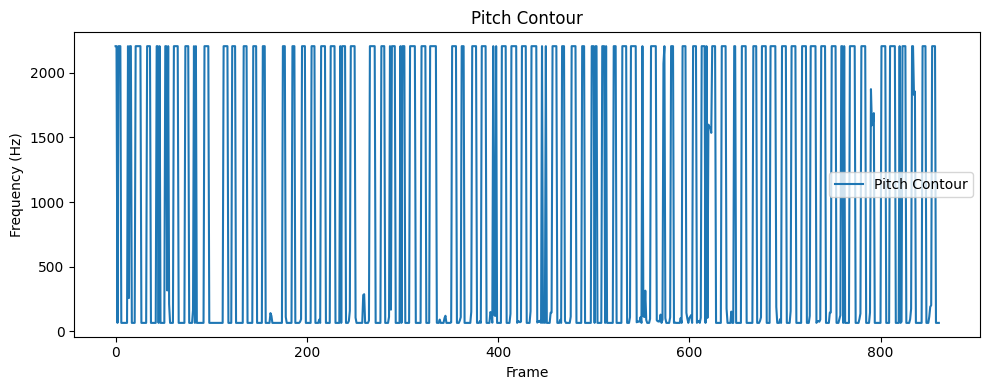

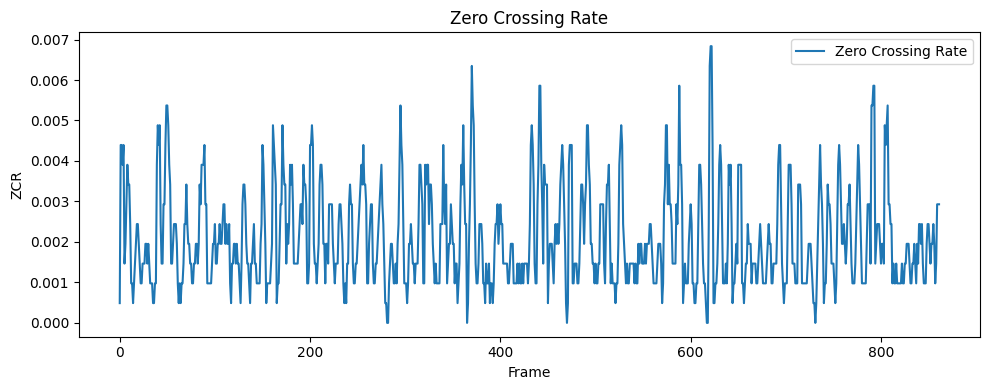

In [22]:
# Audio feature visualization
sample_path = diagnosis_data()[0].image_path
y, sr = librosa.load(sample_path)

plt.figure(figsize=(10, 4))
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
plt.title('Mel Spectrogram')
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

f0 = librosa.yin(y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'))

plt.figure(figsize=(10, 4))
plt.plot(f0, label='Pitch Contour')
plt.xlabel('Frame')
plt.ylabel('Frequency (Hz)')
plt.title('Pitch Contour')
plt.legend()
plt.tight_layout()
plt.show()

zcr = librosa.feature.zero_crossing_rate(y)[0]

plt.figure(figsize=(10, 4))
plt.plot(zcr, label='Zero Crossing Rate')
plt.xlabel('Frame')
plt.ylabel('ZCR')
plt.title('Zero Crossing Rate')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Preprocessing
def preprocessing(labels, images):
    images = np.delete(images, np.where((labels == 7) | (labels == 6))[0], axis=0) 
    labels = np.delete(labels, np.where((labels == 7) | (labels == 6))[0], axis=0)     
    return images, labels

In [24]:
# Data preparation
start = timer()
try:
    labels, images = data_points()
    images, labels = preprocessing(labels, images)
    print('Final shapes:', images.shape, labels.shape)
except Exception as e:
    print(f"Error during data preparation: {e}")
print('Time taken: ', (timer() - start))

C:\Users\NAMAN\AppData\Local\Temp\ipykernel_20472\1291806968.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  diag_dict[row[0]] = row.iloc[1]


Processing 1/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/101_1b1_Al_sc_Meditron.wav


c:\Users\NAMAN\OneDrive\Desktop\VT Project\ML_Zip_Model\venv\Lib\site-packages\librosa\core\pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Processing 2/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/101_1b1_Pr_sc_Meditron.wav
Processing 3/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/102_1b1_Ar_sc_Meditron.wav
Processing 4/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/103_2b2_Ar_mc_LittC2SE.wav
Processing 5/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/104_1b1_Al_sc_Litt3200.wav
Processing 6/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/104_1b1_Ar_sc_Litt3200.wav
Processing 7/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/104_1b1_Ll_sc_Litt3200.wav
Processing 8/920: extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/104_1b1_Lr_sc_Litt3200.wav
Processing 9/920: extracted_dataset/Respi

In [25]:
# Model Architectures & K-Fold Training
def build_cnn_model():
    model = Sequential()
    model.add(Conv1D(64, kernel_size=5, activation='relu', input_shape=(images.shape[1], 1)))
    model.add(Conv1D(128, kernel_size=5, activation='relu'))
    model.add(MaxPooling1D(2)) 
    model.add(Conv1D(256, kernel_size=5, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))    
    model.add(Dense(6, activation='softmax'))
    
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_hybrid_model():
    model = Sequential()
    model.add(Conv1D(64, kernel_size=5, activation='relu', input_shape=(images.shape[1], 1)))
    model.add(MaxPooling1D(2))
    model.add(Conv1D(128, kernel_size=5, activation='relu'))
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.3))
    model.add(LSTM(64, return_sequences=True))  # Add an LSTM layer
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dense(6, activation='softmax'))
    
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [26]:
model = build_hybrid_model()

# K-Fold Cross-Validation Setup
n_splits = 5 
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=10)

fold_no = 1
histories = []
all_preds = []
all_y_test = []
all_test_losses = []
all_test_accuracies = [] 
all_prob_preds = []     
all_y_test_cat = []      

for train_index, test_index in skf.split(images, labels):
    print(f"----------------------------------- Fold {fold_no} -----------------------------------")
    
    X_train, X_test = images[train_index], images[test_index]
    y_train, y_test = labels[train_index], labels[test_index]

    # Preprocessing
    y_train_cat = to_categorical(y_train)
    y_test_cat = to_categorical(y_test)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

    # Calculate class weights for the current fold
    class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = dict(enumerate(class_weights))

    # Define callbacks for training
    callbacks = [
        ModelCheckpoint(f'model_fold_{fold_no}.h5', monitor='val_loss', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1),
        EarlyStopping(monitor='val_loss', patience=10, verbose=1)
    ]
    
    model = build_hybrid_model()
    history = model.fit(
        X_train, 
        y_train_cat, 
        validation_data=(X_test, y_test_cat), 
        epochs=100, 
        batch_size=200, 
        verbose=1,
        class_weight=class_weights,
        callbacks=callbacks
    )
    histories.append(history)

    # Evaluate the best model from the fold
    from tensorflow.keras.models import Sequential, Model, load_model
    best_model = load_model(f'model_fold_{fold_no}.h5')
    score = best_model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"Fold {fold_no} - Test Loss: {score[0]:.4f}, Test Accuracy: {score[1]:.2%}")
    
    # Append the scores to our new lists
    all_test_losses.append(score[0])
    all_test_accuracies.append(score[1])

    # Store predictions for the confusion matrix and classification report
    preds = best_model.predict(X_test, verbose=0)
    all_prob_preds.extend(preds)                 
    all_preds.extend(np.argmax(preds, axis=1))
    all_y_test.extend(y_test)
    all_y_test_cat.extend(y_test_cat)          

    fold_no += 1

c:\Users\NAMAN\OneDrive\Desktop\VT Project\ML_Zip_Model\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


----------------------------------- Fold 1 -----------------------------------


c:\Users\NAMAN\OneDrive\Desktop\VT Project\ML_Zip_Model\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.3418 - loss: 1.7310
Epoch 1: val_loss improved from inf to 1.15550, saving model to model_fold_1.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - accuracy: 0.3494 - loss: 1.7224 - val_accuracy: 0.5788 - val_loss: 1.1555 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.5755 - loss: 1.4054
Epoch 2: val_loss improved from 1.15550 to 0.94052, saving model to model_fold_1.h5


...

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.9263 - loss: 0.2320 - val_accuracy: 0.8971 - val_loss: 0.2549 - learning_rate: 5.0000e-04
Epoch 51/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9325 - loss: 0.2228
Epoch 51: val_loss did not improve from 0.25494
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.9325 - loss: 0.2227 - val_accuracy: 0.8750 - val_loss: 0.2630 - learning_rate: 5.0000e-04
Epoch 52/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9203 - loss: 0.2101
Epoch 52: val_loss did not improve from 0.25494
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.9200 - loss: 0.2115 - val_accuracy: 0.8860 - val_loss: 0.2651 - learning_rate: 5.0000e-04
Epoch 53/100
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9099 - loss: 0.2388
Epoch 53: val_loss did not improve from 0.25494
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.9136 - loss: 0.2309 - val_accuracy: 0.9007 - val_loss: 0.2561 - learning_rate: 5.0000e-04
Epoch 54/100
5/6 ━━━━━━━━━━━━

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.9307 - loss: 0.1745 - val_accuracy: 0.9044 - val_loss: 0.2494 - learning_rate: 2.5000e-04
Epoch 59/100
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9385 - loss: 0.1825
Epoch 59: val_loss did not improve from 0.24938
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9390 - loss: 0.1799 - val_accuracy: 0.9044 - val_loss: 0.2520 - learning_rate: 2.5000e-04
Epoch 60/100
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9419 - loss: 0.1769
Epoch 60: val_loss did not improve from 0.24938
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.9415 - loss: 0.1777 - val_accuracy: 0.9118 - val_loss: 0.2516 - learning_rate: 2.5000e-04
Epoch 61/100
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9349 - loss: 0.1690
Epoch 61: val_loss did not improve from 0.24938
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9333 - loss: 0.1703 - val_accuracy: 0.8824 - val_loss: 0.2679 - learning_rate: 2.5000e-04
Epoch 62/100
5/6 ━━━━━━━━━━━━━━━

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.9507 - loss: 0.1458 - val_accuracy: 0.9044 - val_loss: 0.2492 - learning_rate: 1.2500e-04
Epoch 65/100
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9456 - loss: 0.1337
Epoch 65: val_loss did not improve from 0.24917
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9423 - loss: 0.1432 - val_accuracy: 0.9007 - val_loss: 0.2538 - learning_rate: 1.2500e-04
Epoch 66/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9388 - loss: 0.1565
Epoch 66: val_loss did not improve from 0.24917
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.9384 - loss: 0.1573 - val_accuracy: 0.8897 - val_loss: 0.2609 - learning_rate: 1.2500e-04
Epoch 67/100
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9299 - loss: 0.1711
Epoch 67: val_loss did not improve from 0.24917
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9319 - loss: 0.1700 - val_accuracy: 0.9081 - val_loss: 0.2520 - learning_rate: 1.2500e-04
Epoch 68/100
5/6 ━━━━━━━━━━━━━━━

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.9435 - loss: 0.1608 - val_accuracy: 0.9154 - val_loss: 0.2424 - learning_rate: 1.2500e-04
Epoch 69/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9431 - loss: 0.1551
Epoch 69: val_loss did not improve from 0.24244
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.9430 - loss: 0.1558 - val_accuracy: 0.9118 - val_loss: 0.2462 - learning_rate: 1.2500e-04
Epoch 70/100
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9497 - loss: 0.1527
Epoch 70: val_loss did not improve from 0.24244
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9496 - loss: 0.1546 - val_accuracy: 0.9081 - val_loss: 0.2468 - learning_rate: 1.2500e-04
Epoch 71/100
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9576 - loss: 0.1540
Epoch 71: val_loss did not improve from 0.24244
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9553 - loss: 0.1518 - val_accuracy: 0.9044 - val_loss: 0.2453 - learning_rate: 1.2500e-04
Epoch 72/100
5/6 ━━━━━━━━━━━━━━

Fold 5 - Test Loss: 0.2424, Test Accuracy: 91.54%


In [27]:
print("\n----------------------------------- Average K-Fold Results -----------------------------------")
avg_loss = np.mean(all_test_losses)
avg_acc = np.mean(all_test_accuracies)
print(f"Average Test Loss: {avg_loss:.4f}")
print(f"Average Test Accuracy: {avg_acc:.2%}")


----------------------------------- Average K-Fold Results -----------------------------------
Average Test Loss: 0.2562
Average Test Accuracy: 90.90%


In [28]:
# Train a final model on the entire dataset
print("\n----------------------------------- Training Final Model -----------------------------------")

final_model = build_hybrid_model()

y_cat = to_categorical(labels)
X = np.reshape(images, (images.shape[0], images.shape[1], 1))

class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(class_weights))

final_model.fit(
    X,
    y_cat,
    epochs=100,
    batch_size=200,
    verbose=1,
    class_weight=class_weights,
    validation_split=0.2, 
    callbacks=callbacks
)

final_model.save('final_model.h5')
print("\nFinal model saved as 'final_model.h5'.")


----------------------------------- Training Final Model -----------------------------------
Epoch 1/100
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.2155 - loss: 1.6836
Epoch 1: val_loss did not improve from 0.24244
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 262ms/step - accuracy: 0.2497 - loss: 1.6674 - val_accuracy: 0.6190 - val_loss: 1.3012 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.4958 - loss: 1.4255
Epoch 2: val_loss did not improve from 0.24244
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.5030 - loss: 1.4166 - val_accuracy: 0.6667 - val_loss: 0.9059 - learning_rate: 0.0010
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.6846 - loss: 1.1463 
Epoch 3: val_loss did not improve from 0.24244
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.6854 - loss: 1.1395 - val_accuracy: 0.6960 - val_loss: 0.7576 - learning_rate: 0.0010
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6674 - loss: 1.0614
Epoch 4: va


Final model saved as 'final_model.h5'.


In [29]:
model_loaded = load_model('final_model.h5')

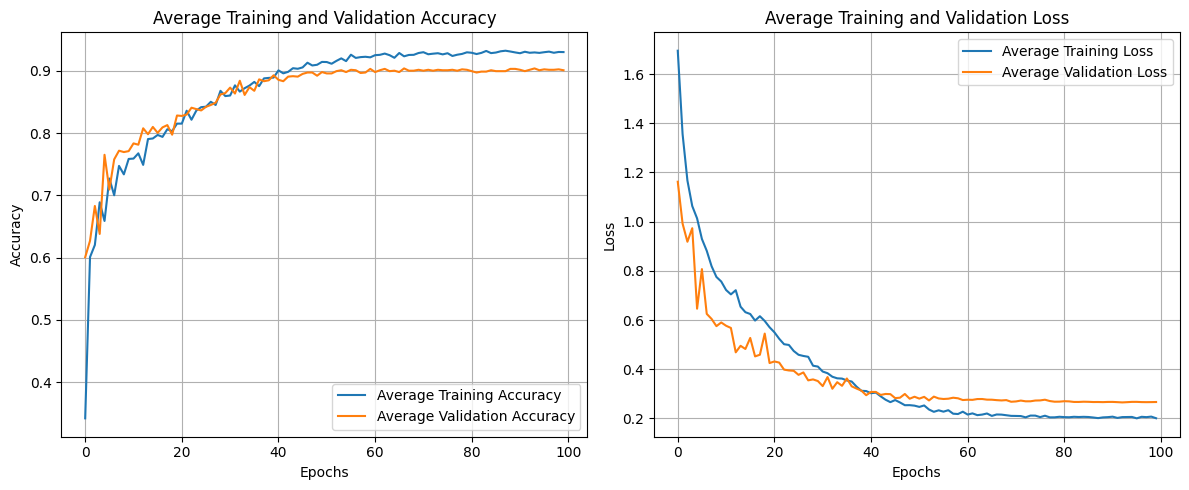

In [30]:
def plot_kfold_history(histories):
    
    all_train_loss = [h.history['loss'] for h in histories]
    all_val_loss = [h.history['val_loss'] for h in histories]
    all_train_acc = [h.history['accuracy'] for h in histories]
    all_val_acc = [h.history['val_accuracy'] for h in histories]

    max_epochs = max(len(h) for h in all_train_loss)
    
    def pad_history(hist_list):
        padded_hist = []
        for hist in hist_list:
            if len(hist) < max_epochs:
                padded_hist.append(hist + [hist[-1]] * (max_epochs - len(hist)))
            else:
                padded_hist.append(hist)
        return np.array(padded_hist)

    avg_train_loss = np.mean(pad_history(all_train_loss), axis=0)
    avg_val_loss = np.mean(pad_history(all_val_loss), axis=0)
    avg_train_acc = np.mean(pad_history(all_train_acc), axis=0)
    avg_val_acc = np.mean(pad_history(all_val_acc), axis=0)
    
    epochs_range = range(max_epochs)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, avg_train_acc, label='Average Training Accuracy')
    plt.plot(epochs_range, avg_val_acc, label='Average Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Average Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, avg_train_loss, label='Average Training Loss')
    plt.plot(epochs_range, avg_val_loss, label='Average Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Average Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_kfold_history(histories)


----------------------------------- Final Results -----------------------------------
                precision    recall  f1-score   support

          COPD       0.97      0.95      0.96       793
       Healthy       0.42      0.66      0.51        35
          URTI       0.86      0.80      0.83       138
Bronchiectasis       0.91      0.95      0.93        96
     Pneumoina       0.87      0.88      0.87       222
 Bronchiolitis       0.81      0.86      0.83        78

      accuracy                           0.91      1362
     macro avg       0.81      0.85      0.82      1362
  weighted avg       0.92      0.91      0.91      1362



C:\Users\NAMAN\AppData\Local\Temp\ipykernel_20472\1746643118.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


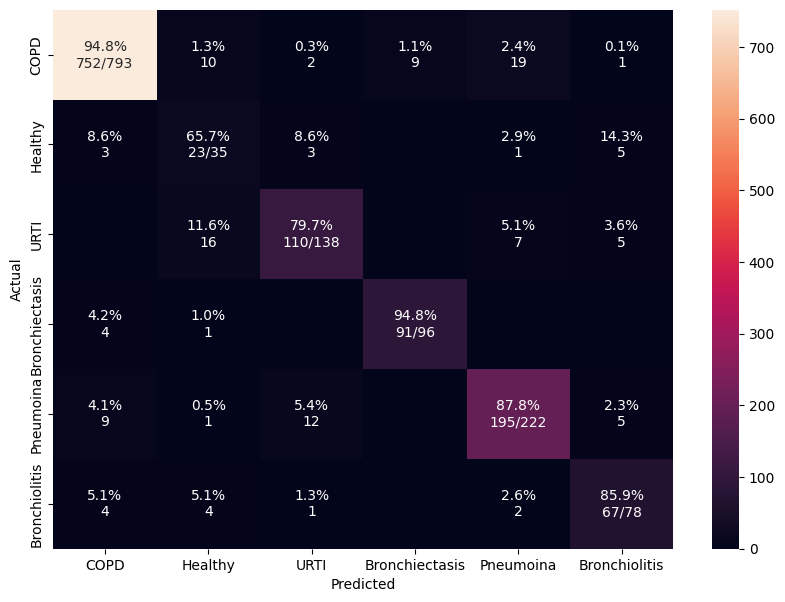

In [31]:
print("\n----------------------------------- Final Results -----------------------------------")
matrix_index = ["COPD", "Healthy", "URTI", "Bronchiectasis", "Pneumoina", "Bronchiolitis"]
print(classification_report(all_y_test, all_preds, target_names=matrix_index))

cm = confusion_matrix(all_y_test, all_preds)
cm_sum = np.sum(cm, axis=1, keepdims=True)
cm_perc = cm / cm_sum.astype(float) * 100
annot = np.empty_like(cm).astype(str)
nrows, ncols = cm.shape
for i in range(nrows):
    for j in range(ncols):
        c = cm[i, j]
        p = cm_perc[i, j]
        if i == j:
            s = cm_sum[i]
            annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
        elif c == 0:
            annot[i, j] = ''
        else:
            annot[i, j] = '%.1f%%\n%d' % (p, c)

df_cm = pd.DataFrame(cm, index = matrix_index, columns = matrix_index)
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
fig, ax = plt.subplots(figsize=(10,7))
sn.heatmap(df_cm, annot=annot, fmt='')
plt.show()

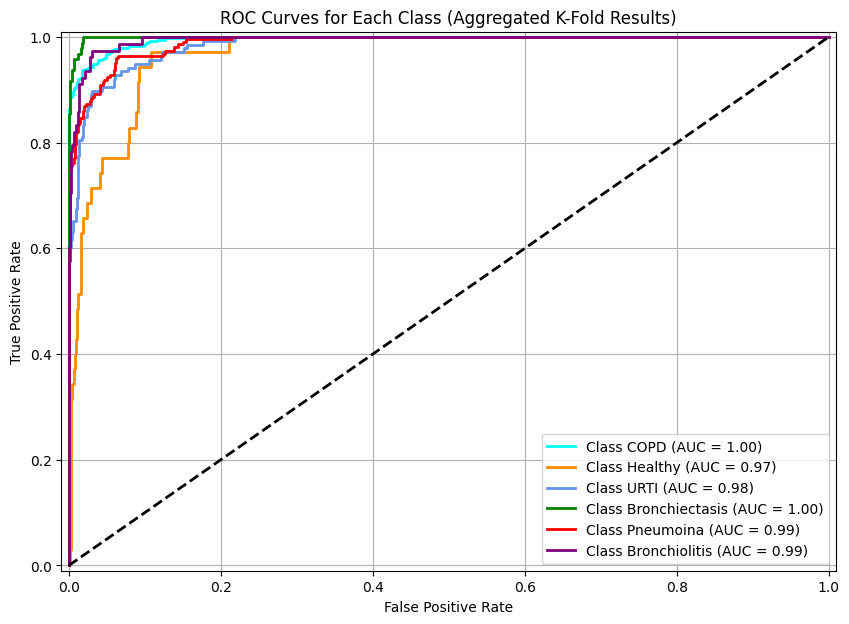

In [32]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

all_y_test_cat = np.array(all_y_test_cat)
all_prob_preds = np.array(all_prob_preds)

n_classes = all_y_test_cat.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(all_y_test_cat[:, i], all_prob_preds[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 7))
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {matrix_index[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Class (Aggregated K-Fold Results)')
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [33]:
import os

print(os.path.exists('final_model.h5'))

True


In [34]:
from tensorflow.keras.models import load_model

model_loaded = load_model('final_model.h5')
model_loaded.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 189, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 94, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 90, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 45, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 45, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 45, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2880)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     1,475,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569,032 (5.99 MB)

 Trainable params: 1,569,030 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [35]:
import os 

index_to_label = {0: "COPD", 1: "Healthy", 2: "URTI", 3: "Bronchiectasis", 4: "Pneumonia", 5: "Bronchiolitis"}

def get_diagnosis_dict():
    diagnosis_list = diagnosis_data()
    diag_dict = {}
    for diag_obj in diagnosis_list:
        try:
            filename = os.path.basename(diag_obj.image_path)
            patient_id = int(filename.split('_')[0])
            diag_dict[patient_id] = diag_obj.diagnosis
        except (ValueError, IndexError) as e:
            print(f"Skipping malformed filename: {diag_obj.image_path} - Error: {e}")
            continue
    return diag_dict

diagnosis_dict = get_diagnosis_dict()

def predict_disease_from_audio(file_path):
    filename = os.path.basename(file_path)
    
    try:
        patient_id = int(filename.split('_')[0])
        actual_disease = diagnosis_dict.get(patient_id, "Unknown")
    except (ValueError, IndexError) as e:
        actual_disease = "Unknown (Error in filename)"
        print(f"Could not parse patient ID from filename: {filename} - Error: {e}")
    
    features = audio_features(file_path)
    
    features = np.reshape(features, (1, features.shape[0], 1))
    
    prediction = model_loaded.predict(features, verbose=0)
    predicted_class = np.argmax(prediction)
    predicted_label = index_to_label[predicted_class]
    
    print(f" Predicted Disease: {predicted_label}")
    print(f"Prediction Probabilities:\n{dict(zip(index_to_label.values(), prediction[0]))}")

test_file_path = 'extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/117_1b3_Tc_mc_LittC2SE.wav'
predict_disease_from_audio(test_file_path)

test_file_path = 'extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/121_1p1_Tc_sc_Meditron.wav'
predict_disease_from_audio(test_file_path)

test_file_path = 'extracted_dataset/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/226_1b1_Pl_sc_LittC2SE.wav'
predict_disease_from_audio(test_file_path)

# Random wav file
test_file_path = '151213__owlstorm__cough-female.wav'
predict_disease_from_audio(test_file_path)


C:\Users\NAMAN\AppData\Local\Temp\ipykernel_20472\1291806968.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  diag_dict[row[0]] = row.iloc[1]


 Predicted Disease: Bronchiectasis
Prediction Probabilities:
{'COPD': np.float32(0.20895928), 'Healthy': np.float32(0.09822388), 'URTI': np.float32(0.12555157), 'Bronchiectasis': np.float32(0.49337393), 'Pneumonia': np.float32(0.00018799394), 'Bronchiolitis': np.float32(0.073703416)}
 Predicted Disease: Healthy
Prediction Probabilities:
{'COPD': np.float32(0.0062755174), 'Healthy': np.float32(0.95088506), 'URTI': np.float32(0.017242793), 'Bronchiectasis': np.float32(0.00020969175), 'Pneumonia': np.float32(6.19177e-05), 'Bronchiolitis': np.float32(0.025325025)}
 Predicted Disease: Healthy
Prediction Probabilities:
{'COPD': np.float32(0.0009140797), 'Healthy': np.float32(0.8237761), 'URTI': np.float32(0.1258984), 'Bronchiectasis': np.float32(2.9746747e-05), 'Pneumonia': np.float32(0.0069556935), 'Bronchiolitis': np.float32(0.042425886)}
 Predicted Disease: Bronchiectasis
Prediction Probabilities:
{'COPD': np.float32(0.36361045), 'Healthy': np.float32(0.00017428592), 'URTI': np.float32(0.

c:\Users\NAMAN\OneDrive\Desktop\VT Project\ML_Zip_Model\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=769
  warnings.warn(
c:\Users\NAMAN\OneDrive\Desktop\VT Project\ML_Zip_Model\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=385
  warnings.warn(


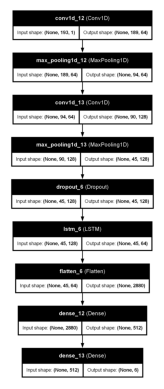

In [36]:
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
plot_model(model_loaded, to_file='cnn_model_loaded.png', show_shapes=True, show_layer_names=True)
plt.imshow(plt.imread('cnn_model_loaded.png'))
plt.axis('off')
plt.show()